# Naive Bayes Churn Risk Scoring Model
## HPB Fintech Hackathon 2026

**Objective:** Train a Gaussian Naive Bayes classifier on the 10 selected churn features, find the optimal probability threshold to maximize F1 score, and output a per-customer churn risk score.

### Pipeline
1. Load the pre-built training dataset (`churn_training.csv`)
2. Train/test split (stratified 75/25)
3. Feature scaling (StandardScaler)
4. Train GaussianNB
5. Sweep probability thresholds to maximize F1
6. Evaluate on test set at optimal threshold
7. Output risk scores for every customer

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

DATA = Path('../data')
print("Libraries loaded")

Libraries loaded


In [ ]:
# ── 1. Load Dataset ──
df = pd.read_csv(DATA / 'churn_training.csv')

FEATURES = [
    'PRIMA_PLACU', 'n_products', 'n_transactions', 'has_kredit',
    'has_contact', 'TENURE_YEARS', 'latest_balance', 'negative_balance',
    'total_amount', 'DOB',
]
TARGET = 'CHURNED'

X = df[FEATURES]
y = df[TARGET]

print(f"Dataset: {df.shape[0]:,} clients, {len(FEATURES)} features")
print(f"Churn distribution: {y.value_counts().to_dict()}")
print(f"Churn rate: {y.mean():.1%}")
X.describe().round(2)

Dataset: 11,997 clients, 9 features
Churn distribution: {1: 9022, 0: 2975}
Churn rate: 75.2%


,PRIMA_PLACU,n_transactions,has_kredit,has_contact,TENURE_YEARS,latest_balance,negative_balance,total_amount,DOB
count,11997.00,11997.0,11997.00,11997.00,11997.00,11997.00,11997.00,11997.00,11997.00
mean,0.17,87.4,0.09,0.42,15.29,972.56,0.04,18965.48,59.31
std,0.38,232.0,0.29,0.49,8.20,6609.88,0.19,120785.98,18.62
min,0.00,0.0,0.00,0.00,0.16,-131933.66,0.00,0.00,0.00
25%,0.00,0.0,0.00,0.00,8.59,0.00,0.00,0.00,48.00
50%,0.00,1.0,0.00,0.00,17.52,0.00,0.00,2.65,59.00
75%,0.00,60.0,0.00,1.00,19.92,0.00,0.00,9941.47,71.00
max,1.00,4539.0,1.00,1.00,46.25,255468.53,1.00,5869617.26,829.00


In [3]:
# ── 2. Train/Test Split & Scaling ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train churn rate: {y_train.mean():.1%}  |  Test churn rate: {y_test.mean():.1%}")

Train: 8,997  |  Test: 3,000
Train churn rate: 75.2%  |  Test churn rate: 75.2%


In [4]:
# ── 3. Train Gaussian Naive Bayes ──
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

# Get probability scores on test set
y_proba_test = gnb.predict_proba(X_test_scaled)[:, 1]  # P(churned)

print(f"Model trained: GaussianNB")
print(f"ROC AUC (test): {roc_auc_score(y_test, y_proba_test):.4f}")

Model trained: GaussianNB
ROC AUC (test): 0.9794


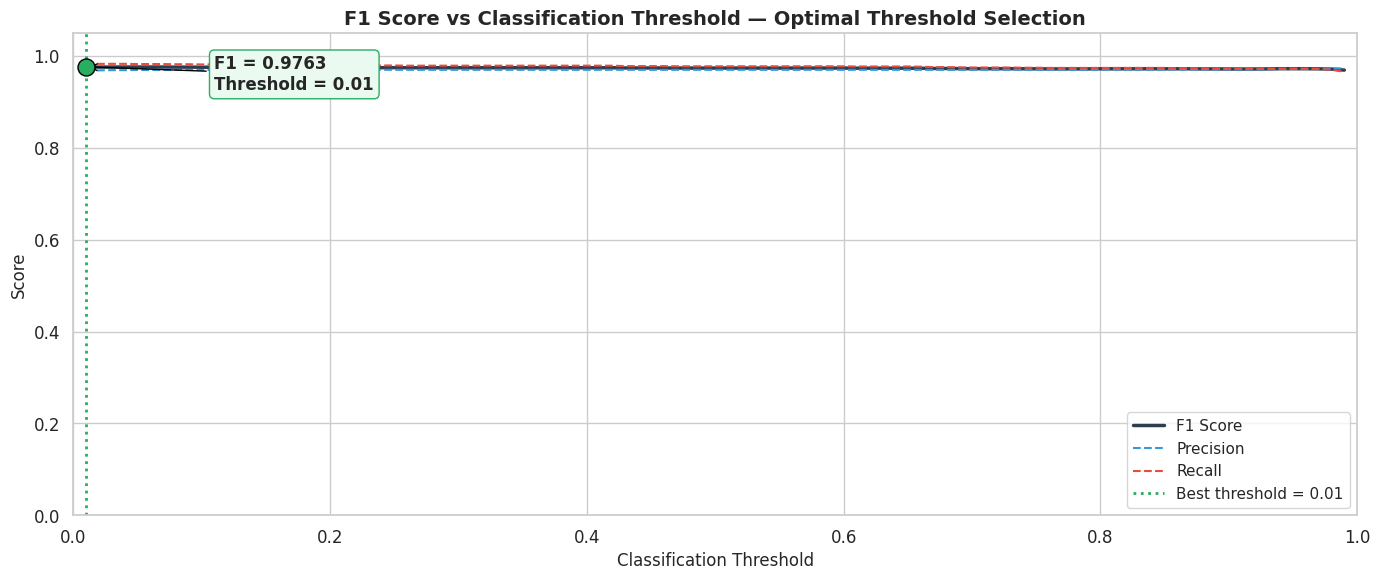

Optimal threshold: 0.01
F1 at optimal:     0.9763
Precision:          0.9686
Recall:             0.9840


In [5]:
# ── 4. Find Optimal Threshold to Maximize F1 Score ──
thresholds = np.arange(0.01, 1.0, 0.01)
f1_scores = []
precision_scores = []
recall_scores = []

for t in thresholds:
    y_pred_t = (y_proba_test >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t))
    precision_scores.append(precision_score(y_test, y_pred_t, zero_division=0))
    recall_scores.append(recall_score(y_test, y_pred_t))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(thresholds, f1_scores, color='#2c3e50', linewidth=2.5, label='F1 Score')
ax.plot(thresholds, precision_scores, color='#3498db', linewidth=1.5, linestyle='--', label='Precision')
ax.plot(thresholds, recall_scores, color='#e74c3c', linewidth=1.5, linestyle='--', label='Recall')
ax.axvline(x=best_threshold, color='#27ae60', linewidth=2, linestyle=':', label=f'Best threshold = {best_threshold:.2f}')
ax.scatter([best_threshold], [best_f1], color='#27ae60', s=150, zorder=5, edgecolors='black')
ax.annotate(f'F1 = {best_f1:.4f}\nThreshold = {best_threshold:.2f}',
            xy=(best_threshold, best_f1), xytext=(best_threshold + 0.1, best_f1 - 0.05),
            fontsize=12, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black'),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#eafaf1', edgecolor='#27ae60'))
ax.set_xlabel('Classification Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('F1 Score vs Classification Threshold — Optimal Threshold Selection', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print(f"Optimal threshold: {best_threshold:.2f}")
print(f"F1 at optimal:     {best_f1:.4f}")
print(f"Precision:          {precision_scores[best_idx]:.4f}")
print(f"Recall:             {recall_scores[best_idx]:.4f}")

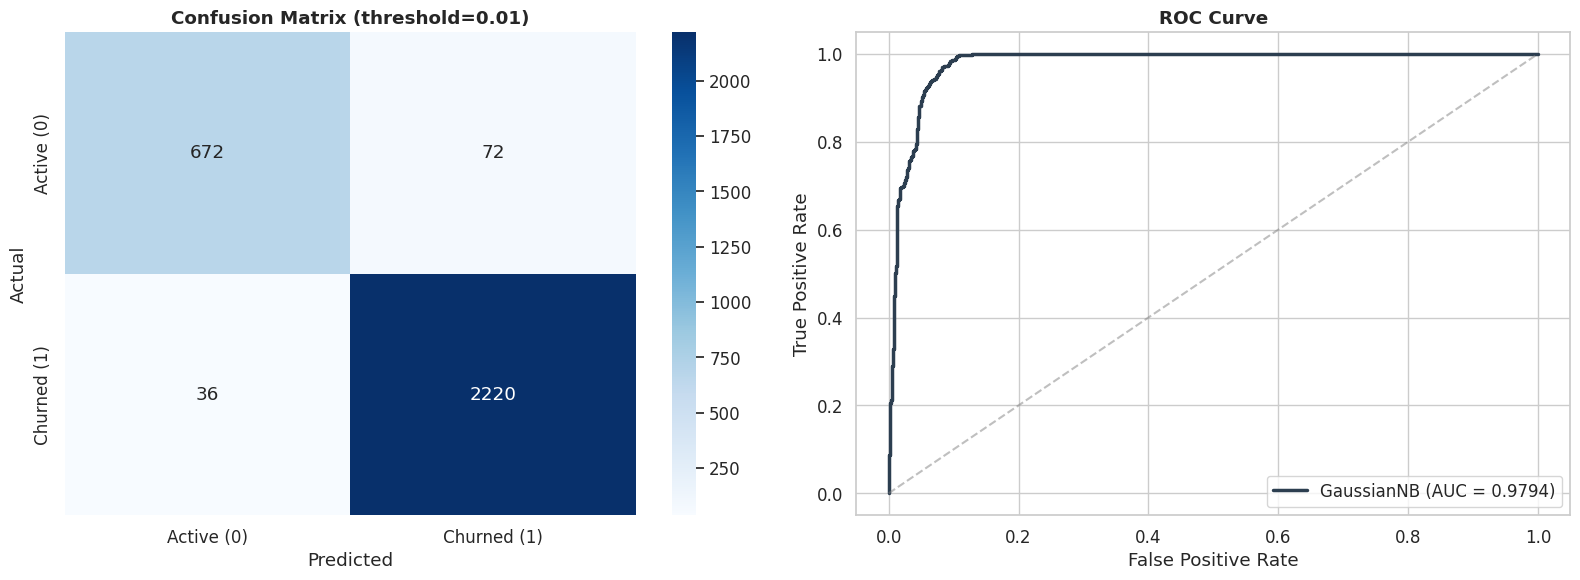

              precision    recall  f1-score   support

      Active       0.95      0.90      0.93       744
     Churned       0.97      0.98      0.98      2256

    accuracy                           0.96      3000
   macro avg       0.96      0.94      0.95      3000
weighted avg       0.96      0.96      0.96      3000



In [6]:
# ── 5. Evaluate at Optimal Threshold ──
y_pred_optimal = (y_proba_test >= best_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Active (0)', 'Churned (1)'],
            yticklabels=['Active (0)', 'Churned (1)'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix (threshold={best_threshold:.2f})', fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
auc = roc_auc_score(y_test, y_proba_test)
axes[1].plot(fpr, tpr, color='#2c3e50', linewidth=2.5, label=f'GaussianNB (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_optimal, target_names=['Active', 'Churned']))

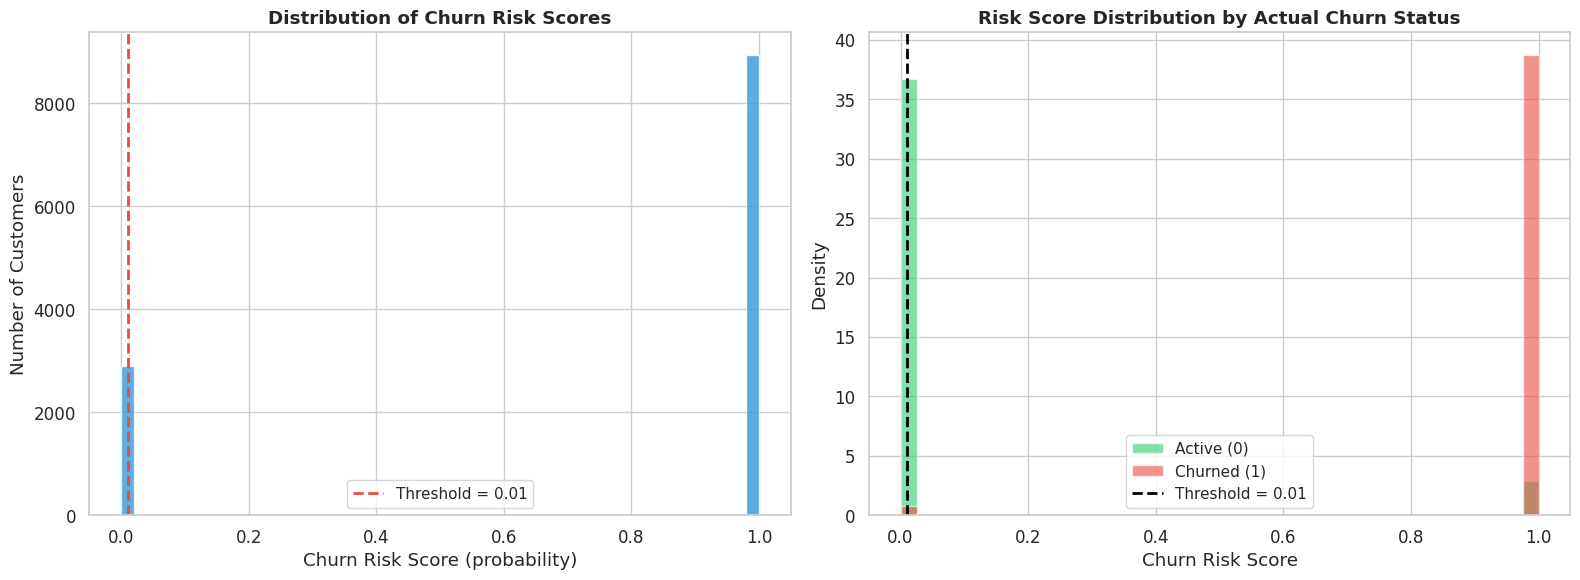

Saved risk scores to: ../data/churn_risk_scores.csv
  High risk (predicted churn): 9,098 (75.8%)
  Low risk (predicted active): 2,899 (24.2%)

Top 10 highest-risk customers:


,IDENTIFIKATOR_KLIJENTA,churn_risk_score,predicted_churn
0,E6X0TSNIR4MG,1.0,1
1,PTDX2YILL3TG,1.0,1
2,Z9UG1YHODSK3,1.0,1
3,18YWHACUWKTB,1.0,1
4,ID47TU91MKPJ,1.0,1
5,MDYEYZH7VYBS,1.0,1
6,QPKSQ7YGK5AE,1.0,1
7,PS3ZNK7K81TR,1.0,1
8,ALA6QQYYYU7N,1.0,1
9,MV213CT536VQ,1.0,1


In [7]:
# ── 6. Risk Scores for All Customers ──
X_all_scaled = scaler.transform(X)
risk_proba = gnb.predict_proba(X_all_scaled)[:, 1]

risk_output = df[['IDENTIFIKATOR_KLIJENTA']].copy()
risk_output['churn_risk_score'] = risk_proba
risk_output['predicted_churn'] = (risk_proba >= best_threshold).astype(int)
risk_output = risk_output.sort_values('churn_risk_score', ascending=False).reset_index(drop=True)

# Save to CSV
risk_path = DATA / 'churn_risk_scores.csv'
risk_output.to_csv(risk_path, index=False)

# Distribution of risk scores
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(risk_output['churn_risk_score'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(x=best_threshold, color='#e74c3c', linewidth=2, linestyle='--',
                label=f'Threshold = {best_threshold:.2f}')
axes[0].set_xlabel('Churn Risk Score (probability)')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Distribution of Churn Risk Scores', fontweight='bold')
axes[0].legend(fontsize=11)

# Risk score by actual churn status
for label, color in [('Active (0)', '#2ecc71'), ('Churned (1)', '#e74c3c')]:
    val = 0 if 'Active' in label else 1
    subset = risk_proba[y == val]
    axes[1].hist(subset, bins=40, alpha=0.6, color=color, edgecolor='white', label=label, density=True)
axes[1].axvline(x=best_threshold, color='black', linewidth=2, linestyle='--', label=f'Threshold = {best_threshold:.2f}')
axes[1].set_xlabel('Churn Risk Score')
axes[1].set_ylabel('Density')
axes[1].set_title('Risk Score Distribution by Actual Churn Status', fontweight='bold')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

n_high = (risk_output['predicted_churn'] == 1).sum()
n_low = (risk_output['predicted_churn'] == 0).sum()
print(f"Saved risk scores to: {risk_path}")
print(f"  High risk (predicted churn): {n_high:,} ({n_high/len(risk_output):.1%})")
print(f"  Low risk (predicted active): {n_low:,} ({n_low/len(risk_output):.1%})")
print(f"\nTop 10 highest-risk customers:")
risk_output.head(10)